26/03/2026 Thursday H5

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM , Dense, Dropout,Embedding
from tensorflow.keras.utils import to_categorical

In [10]:
with open("alice.txt", "r", encoding="utf-8") as f:
    text = f.read()

import re

# 1. Fix hyphenated words (join split words)
text = re.sub(r'(\w)-(\w)', r'\1\2', text)

# 2. Remove multiple hyphens
text = re.sub(r'-+', '', text)

# 3. Lowercase
text = text.lower()

# 4. Keep letters + sentence delimiter
text = re.sub(r'[^a-z\s.]', '', text)

# 5. Remove extra spaces
text = re.sub(r'\s+', ' ', text)

# 6. Split into sentences
text = text.split('.')

# 7. Remove short/empty lines
text = [line.strip() for line in text if len(line.split()) > 1]

In [28]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(text)

total_words = min(5000, len(tokenizer.word_index) + 1)

input_sequences = []

for line in text:
    token_list = tokenizer.texts_to_sequences([line])[0]
    
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

max_len = max(len(x) for x in input_sequences)

input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

x, y = input_sequences[:, :-1], input_sequences[:, -1]

# Debug AFTER processing
print("X shape:", x.shape)
print("y shape:", y.shape)
print("Sample y:", y[:10])

X shape: (21834, 116)
y shape: (21834,)
Sample y: [ 41  43 257   5  12  10 443 222  10 113]


In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
model = Sequential()
model.add(Embedding(total_words,100,input_length=max_len-1))
model.add(LSTM(150))
model.add(Dropout(0.2))
model.add(Dense(total_words,activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [32]:
print("Total words:", total_words)

Total words: 2199


In [33]:
print(y_train[:20])

[  29 1078   10  115  260  436  752   44   13   92   24  138    9  160
   13   10   76   93 2157  305]


In [59]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 116, 100)       │       219,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 150)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2199)           │       332,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,107,649 (8.04 MB)

 Trainable params: 702,549 (2.68 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,405,100 (5.36 MB)

In [34]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history = model.fit(x_train, y_train, epochs=100, batch_size=64, validation_data=(x_test, y_test), callbacks=[early_stop])

Epoch 1/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 35s 121ms/step - accuracy: 0.0595 - loss: 6.1166 - val_accuracy: 0.0554 - val_loss: 5.8918
Epoch 2/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 32s 116ms/step - accuracy: 0.0639 - loss: 5.7688 - val_accuracy: 0.0760 - val_loss: 5.8237
Epoch 3/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 33s 120ms/step - accuracy: 0.0836 - loss: 5.5342 - val_accuracy: 0.0888 - val_loss: 5.6417
Epoch 4/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 32s 117ms/step - accuracy: 0.1063 - loss: 5.2724 - val_accuracy: 0.1108 - val_loss: 5.4915
Epoch 5/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.1229 - loss: 5.0372 - val_accuracy: 0.1193 - val_loss: 5.3720
Epoch 6/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 33s 121ms/step - accuracy: 0.1368 - loss: 4.8248 - val_accuracy: 0.1269 - val_loss: 5.2903
Epoch 7/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 33s 121ms/step - accuracy: 0.1538 - loss: 4.6406 - val_accuracy: 0.1376 - val_loss: 5.2292
Epoch 8/100
273/273 ━━━━━━━━━━━━━━━━━━━━ 33s 121ms/step - accuracy: 0.1674 -

In [58]:
def predict_next_word(text):
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    return tokenizer.index_word[np.argmax(predicted)]

#Example usage
input_text = "alice was going" 
predicted_word = predict_next_word(input_text)
print(f"Predicted next word: {predicted_word}")

Predicted next word: to


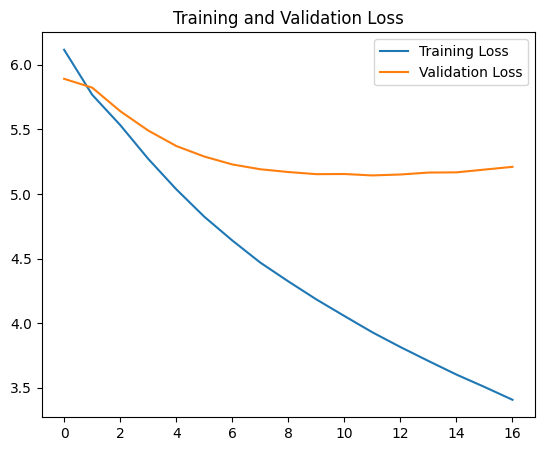

In [36]:
#plot Training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

#plt.savefig('./NEXT_WORD_PREDICTION_LSTM.png')
plt.show()
